In [1]:
import geopandas as gpd
from shapely.geometry import Point, MultiPoint, LineString, MultiLineString
from shapely.ops import split
from geopy.distance import geodesic
import pandas as pd
import os
import re
import networkx as nx
from shapely.geometry import Point, LineString, MultiPolygon, Polygon
from shapely.ops import unary_union # For distance calc
from pyproj import Geod, CRS, Transformer # For distance calc projection
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.sample import sample_gen
import numpy as np
import math
import logging
from contextlib import contextmanager
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import time
from geopy.geocoders import MapBox
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
from tqdm.notebook import tqdm
from dotenv import load_dotenv
import pickle
import requests # Not used currently
import json # Not used currently
#Import required packages and modules
#import qgis
import PyQt5
from aequilibrae import Graph, AequilibraeMatrix, TrafficClass, TrafficAssignment
from aequilibrae.matrix import AequilibraeMatrix
from aequilibrae.paths import Graph
from aequilibrae.paths import TrafficAssignment
from aequilibrae.paths.traffic_class import TrafficClass
#from qgis.core import QgsVectorLayer, QgsField, QgsFeature, QgsPointXY, QgsProject, QgsGeometry, QgsVectorFileWriter
from PyQt5.QtCore import QVariant 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import ast

In [ ]:
def split_network(geojson_path):
    # Load your GeoJSON file
    gdf = gpd.read_file(geojson_path)
    lines = [geom for geom in gdf.geometry if geom.type == "LineString"]
    for geom in gdf.geometry:
        if geom.type == "MultiLineString":
            lines.extend(list(geom.geoms))
    intersection_points = []
    for i, line1 in enumerate(lines):
        for j, line2 in enumerate(lines):
            if i >= j:
                continue
            inter = line1.intersection(line2)
            if inter.is_empty:
                continue
            if isinstance(inter, Point):
                intersection_points.append(inter)
            elif isinstance(inter, MultiPoint):
                intersection_points.extend([pt for pt in inter.geoms])
    if intersection_points:
        intersection_points = list({(round(pt.x, 8), round(pt.y, 8)): pt for pt in intersection_points}.values())
    def split_line_at_points(line, points):
        splitters = [pt for pt in points if line.distance(pt) < 1e-8]
        if not splitters:
            return [line]
        result = split(line, MultiPoint(splitters))
        return list(result.geoms)
    split_lines = []
    for line in lines:
        segments = split_line_at_points(line, intersection_points)
        split_lines.extend(segments)
    nodes = []
    for seg in split_lines:
        nodes.append(Point(seg.coords[0]))
        nodes.append(Point(seg.coords[-1]))
    if intersection_points:
        nodes.extend(intersection_points)
    nodes = list({(round(pt.x, 8), round(pt.y, 8)): pt for pt in nodes}.values())
    split_gdf = gpd.GeoDataFrame(geometry=split_lines)
    nodes_gdf = gpd.GeoDataFrame(geometry=nodes)
    return split_lines, nodes_gdf

In [ ]:
# Set folder path and pattern
folder_path = 'C:/Users/Dean/Downloads/IfW/New folder'  # Replace with your actual folder path
file_path = 'appended_landings_with_regions.xlsx'

# Check if Excel file exists and read it if it does
if os.path.isfile(file_path):
    df = pd.read_excel(file_path)
else:
    print(f"Warning: {file_path} not found. Proceeding without Excel matching.")
    df = pd.DataFrame()

all_nodes_dfs = []
all_edges_dfs = []

pattern = re.compile(r'_(\d{4})\.geojson$')

for filename in os.listdir(folder_path):
    if filename.endswith('.geojson'):
        match = pattern.search(filename)
        if not match:
            continue
        year = int(match.group(1))
        if year < 2025:
            continue
        file_path_geojson = os.path.join(folder_path, filename)
        system_id = filename.split('_')[1]  # e.g. '2005.3'

        # Split network
        split_lines, nodes_gdf = split_network(file_path_geojson)
        if nodes_gdf.empty:
            continue

        # Add blank columns (except Hop_ID)
        nodes_gdf['Node ID'] = ''
        nodes_gdf['Name'] = ''
        nodes_gdf['Longitude'] = nodes_gdf['geometry'].apply(lambda pt: pt.x)
        nodes_gdf['Latitude'] = nodes_gdf['geometry'].apply(lambda pt: pt.y)

        # Filter Excel for this system (if Excel was loaded)
        if not df.empty:
            filtered_df = df[df['system_ID'] == system_id]
        else:
            filtered_df = pd.DataFrame()

        # Match nodes with Excel data (if available)
        precision = 6
        for idx, row in nodes_gdf.iterrows():
            lon = round(row['Longitude'], precision)
            lat = round(row['Latitude'], precision)
            if not filtered_df.empty:
                matches = filtered_df[
                    (round(filtered_df['Longitude'], precision) == lon) &
                    (round(filtered_df['Latitude'], precision) == lat)
                ]
                if not matches.empty:
                    match = matches.iloc[0]
                    lp_city = match['LP_city'] if 'LP_city' in match else ''
                    big_capital = match['BigCountryCapital'] if 'BigCountryCapital' in match else ''
                    nodes_gdf.loc[idx, 'Name'] = f"{lp_city}, {big_capital}" if lp_city and big_capital else ''

                    nodes_gdf.loc[idx, 'Node ID'] = f"pt_{lat}_{lon}"
                else:
                    nodes_gdf.loc[idx, 'Node ID'] = f"grid_{lat}_{lon}"
            else:
                nodes_gdf.loc[idx, 'Node ID'] = f"grid_{lat}_{lon}"

        # Set Name for grid nodes
        for idx, row in nodes_gdf.iterrows():
            if row['Node ID'].startswith('grid'):
                nodes_gdf.at[idx, 'Name'] = row['Node ID']

        # Add system ID and drop geometry
        nodes_gdf['system_ID'] = system_id
        nodes_gdf = nodes_gdf.drop(columns=['geometry'])

        # Process edges
        edges = []
        distances = []
        for line in split_lines:
            start = line.coords[0]
            end = line.coords[-1]
            edges.append(LineString([start, end]))
            dist = geodesic((start[1], start[0]), (end[1], end[0])).km
            distances.append(dist)
        edges_gdf = gpd.GeoDataFrame({'geometry': edges, 'distance_km': distances})
        edges_gdf['Start Coordinates'] = edges_gdf['geometry'].apply(lambda line: line.coords[0])
        edges_gdf['End Coordinates'] = edges_gdf['geometry'].apply(lambda line: line.coords[-1])
        edges_gdf['Edge ID'] = ''
        edges_gdf['Start Node'] = ''
        edges_gdf['Start Name'] = ''
        edges_gdf['End Node'] = ''
        edges_gdf['End Name'] = ''

        # Use node data from this file for matching
        node_name_lookup = {
            (round(row['Longitude'], 6), round(row['Latitude'], 6)): row['Name']
            for idx, row in nodes_gdf.iterrows()
        }
        node_id_lookup = {
            (round(row['Longitude'], 6), round(row['Latitude'], 6)): row['Node ID']
            for idx, row in nodes_gdf.iterrows()
        }
        edges_gdf['Start Name'] = edges_gdf['Start Coordinates'].apply(
            lambda coords: node_name_lookup.get((round(coords[0], 6), round(coords[1], 6)), '')
        )
        edges_gdf['End Name'] = edges_gdf['End Coordinates'].apply(
            lambda coords: node_name_lookup.get((round(coords[0], 6), round(coords[1], 6)), '')
        )
        edges_gdf['Start Node'] = edges_gdf['Start Coordinates'].apply(
            lambda coords: node_id_lookup.get((round(coords[0], 6), round(coords[1], 6)), '')
        )
        edges_gdf['End Node'] = edges_gdf['End Coordinates'].apply(
            lambda coords: node_id_lookup.get((round(coords[0], 6), round(coords[1], 6)), '')
        )
        edges_gdf['Edge ID'] = edges_gdf['Start Node'] + '-' + edges_gdf['End Node']
        edges_gdf['system_ID'] = system_id
        edges_gdf = edges_gdf.drop(columns=['geometry'])

        all_nodes_dfs.append(nodes_gdf)
        all_edges_dfs.append(edges_gdf)

# Combine all results
if all_nodes_dfs:
    all_nodes = pd.concat(all_nodes_dfs, ignore_index=True)
    all_edges = pd.concat(all_edges_dfs, ignore_index=True)
    print(f"Processed {len(all_nodes)} nodes and {len(all_edges)} edges in total.")
else:
    print("No data processed. Check your folder path and files.")

# Assign Hop_ID to all_nodes after concatenation
all_nodes['Hop_ID'] = range(1, len(all_nodes) + 1)

# Fill missing Names in all_nodes using landing and LP_country if available
if 'landing' in all_nodes.columns and 'LP_country' in all_nodes.columns:
    missing_names = all_nodes['Name'].isna() | (all_nodes['Name'] == '')
    all_nodes.loc[missing_names, 'Name'] = all_nodes.loc[missing_names].apply(
        lambda row: f"{row['landing']}, {row['LP_country']}"
        if pd.notna(row['landing']) and pd.notna(row['LP_country'])
        else row['Name'],
        axis=1
    )

# Check if df is available and has required columns
if not df.empty and all(col in df.columns for col in ['Longitude', 'Latitude', 'landing', 'LP_country']):
    precision = 6

    # Create coordinate keys for df (drop duplicates to avoid ambiguity)
    df['coord_key'] = df.apply(
        lambda row: (round(row['Longitude'], precision), round(row['Latitude'], precision)),
        axis=1
    )
    unique_df = df.drop_duplicates('coord_key')
    lookup = unique_df.set_index('coord_key')[['landing', 'LP_country']].to_dict(orient='index')

    # Iterate through all_nodes and update Name where needed
    for idx, row in all_nodes.iterrows():
        # Check if Name is missing or 'nan, nan'
        if pd.isna(row['Name']) or str(row['Name']).lower() == 'nan, nan':
            lon = round(row['Longitude'], precision)
            lat = round(row['Latitude'], precision)
            key = (lon, lat)
            if key in lookup:
                landing = lookup[key].get('landing', '')
                lp_country = lookup[key].get('LP_country', '')
                all_nodes.loc[idx, 'Name'] = f"{landing}, {lp_country}"

# Update edge names based on updated node names
node_id_to_name = all_nodes.set_index('Node ID')['Name'].to_dict()
all_edges['Start Name'] = all_edges['Start Node'].map(node_id_to_name).fillna(all_edges['Start Name'])
all_edges['End Name'] = all_edges['End Node'].map(node_id_to_name).fillna(all_edges['End Name'])

# Remove duplicate edges (same system_ID, distance_km, and node pair, regardless of order)
all_edges['name_pair'] = all_edges.apply(
    lambda row: tuple(sorted([row['Start Name'], row['End Name']])), axis=1
)
all_edges = all_edges.drop_duplicates(
    subset=['system_ID', 'distance_km', 'name_pair'],
    keep='first'
).copy()
all_edges.drop(columns=['name_pair'], inplace=True)

# Optional: Reorder columns for clarity
all_nodes = all_nodes[['Node ID', 'Name', 'Longitude', 'Latitude', 'Hop_ID', 'system_ID']]
all_edges = all_edges[
    ['Edge ID', 'Start Node', 'Start Name', 'Start Coordinates',
     'End Node', 'End Name', 'End Coordinates', 'distance_km', 'system_ID']
]

In [ ]:
all_nodes

In [ ]:
all_edges

In [ ]:
all_edges['start_point_idx'] = None
all_edges['end_point_idx'] = None

# Iterate through edges
for idx, row in all_edges.iterrows():
    system_id = row['system_ID']
    
    # Get Hop_ID for start node (matching both system_ID and Node ID)
    start_match = all_nodes[
        (all_nodes['system_ID'] == system_id) &
        (all_nodes['Node ID'] == row['Start Node'])
    ]['Hop_ID']
    
    # Get Hop_ID for end node (matching both system_ID and Node ID)
    end_match = all_nodes[
        (all_nodes['system_ID'] == system_id) &
        (all_nodes['Node ID'] == row['End Node'])
    ]['Hop_ID']
    
    # Assign values (using first match if multiple exist)
    if not start_match.empty:
        all_edges.at[idx, 'start_point_idx'] = start_match.iloc[0]
    if not end_match.empty:
        all_edges.at[idx, 'end_point_idx'] = end_match.iloc[0]
all_edges

In [ ]:
# Create a new column 'Country' with the value after the last comma in 'Name'
all_nodes['Country'] = all_nodes['Name'].str.split(',').str[-1].str.strip()

In [ ]:
#all_nodes.to_csv("2024FullNetworkNodes.csv", index=False)
#all_edges.to_csv("2024FullNetworkEdges.csv", index=False)

## Traffic Assignment

In [2]:
# 1. Load data
nodes = pd.read_csv("2024FullNetworkNodes.csv")
links = pd.read_csv("2024FullNetworkEdges.csv")
od_data = pd.read_csv("OD.csv")

In [ ]:
#nodes

In [ ]:
#links

In [ ]:
#od_data

In [3]:
# 1. Set relevant_countries to the unique, non-null values in the 'Country' column
relevant_countries = set(nodes['Country'].dropna().unique())

# 2. Read capitals.csv and filter for relevant countries
capitals_raw = pd.read_csv("capitals.csv")
capitals_filtered = capitals_raw[capitals_raw['Country'].isin(relevant_countries)]

# 3. (Optional) Create a dictionary mapping countries to their capitals and coordinates
country_capitals = {
    row['Country']: (row['Capital'], row['Longitude'], row['Latitude'])
    for _, row in capitals_filtered.iterrows()
}

In [ ]:
#relevant_countries

In [ ]:
#country_capitals

In [4]:
# 3. Create capital nodes
max_hop = nodes['Hop_ID'].max()
capital_nodes = []
for idx, (country, (capital, lon, lat)) in enumerate(country_capitals.items(), 1):
    capital_nodes.append({
        'Node ID': f"capital_{country.replace(' ', '_')}",
        'Name': f"{capital}, {country}",
        'Longitude': lon,
        'Latitude': lat,
        'Hop_ID': max_hop + idx
    })
capitals_df = pd.DataFrame(capital_nodes)
nodes = pd.concat([nodes, capitals_df], ignore_index=True)

#nodes

In [ ]:
#capitals_df

In [5]:
# 4. Print unique countries from capital Node IDs
capital_nodes_df = nodes[nodes['Node ID'].str.startswith('capital_')]
unique_countries = capital_nodes_df['Node ID'].apply(lambda x: x.replace('capital_', '').replace('_', ' ')).unique()
# print("Unique countries from Node ID starting with 'capital_':")
# for country in unique_countries:
#     print(country)

# 5. Connect landing points to capitals
capital_links = []
for _, lp in nodes[nodes['Node ID'].str.startswith('pt')].iterrows():
    country = lp['Country']  # Use the country column directly
    #country = lp['Name'].split(', ')[-1]
    if country in country_capitals:
        capital = capitals_df[capitals_df['Name'].str.endswith(country)].iloc[0]
        capital_links.append({
            'Edge ID': f"{lp['Node ID']}-{capital['Node ID']}",
            'Start Node': lp['Node ID'],
            'Start Name': lp['Name'],
            'Start Coordinates': f"({lp['Longitude']}, {lp['Latitude']})",
            'End Node': capital['Node ID'],
            'End Name': capital['Name'],
            'End Coordinates': f"({capital['Longitude']}, {capital['Latitude']})",
            'distance': 50,
            'start_point_idx': lp['Hop_ID'],
            'end_point_idx': capital['Hop_ID']
        })
if capital_links:
    capital_links_df = pd.DataFrame(capital_links)
    links = pd.concat([links, capital_links_df], ignore_index=True)

#links

In [6]:
# Fill empty distance_km with distance
links.loc[links['distance_km'].isna(), 'distance_km'] = links['distance']

# Drop the distance column
links = links.drop(columns=['distance'])
#links

In [7]:
# 6. Create network DataFrame
network = pd.DataFrame({
    'link_id': range(1, len(links)+1),
    'a_node': links['start_point_idx'].astype(int),
    'b_node': links['end_point_idx'].astype(int),
    'direction': 0,
    'capacity': 1000,
    'free_flow_time': links['distance_km'] / 50,  # 50 km/h
    #'preload': 10.0
})

In [ ]:
network

In [8]:
g = Graph()
g.network = network
g.status = 'OK'
centroids = capitals_df['Hop_ID'].unique().astype(int)
g.prepare_graph(centroids)
g.set_graph("free_flow_time")

# 8. Create mapping from country name to capital Hop_ID
country_to_hop = {country: capitals_df[capitals_df['Name'].str.contains(country)]['Hop_ID'].values[0] 
                  for country in country_capitals.keys()}

# 9a Specify multiple countries of interest
# countries_of_interest = ['Thailand', 'South Africa']  # Edit as needed
# 9b Automatically detect all countries present in OD data and in the mapping
all_countries = set(od_data['Country1'].str.strip()) | set(od_data['Country2'].str.strip())
countries_of_interest = sorted([c for c in all_countries if c in country_to_hop])

C:\Users\Dean\anaconda3\Lib\site-packages\aequilibrae\paths\graph.py:246: UserWarning: Found centroids not present in the graph!
  warnings.warn("Found centroids not present in the graph!")
C:\Users\Dean\anaconda3\Lib\site-packages\aequilibrae\paths\graph.py:246: UserWarning: Found centroids not present in the graph!
  warnings.warn("Found centroids not present in the graph!")


In [ ]:
#countries_of_interest

In [9]:
# 10. Prepare OD matrices for each country of interest and for 'others'
od_matrices = {country: np.zeros((len(centroids), len(centroids)), dtype=np.float64) for country in countries_of_interest}
od_matrices['others'] = np.zeros((len(centroids), len(centroids)), dtype=np.float64)

for _, row in od_data.iterrows():
    orig_country = row['Country1'].strip()
    dest_country = row['Country2'].strip()
    flow = row['Flow']
    try:
        orig_hop = country_to_hop[orig_country]
        dest_hop = country_to_hop[dest_country]
        orig_idx = np.where(centroids == orig_hop)[0][0]
        dest_idx = np.where(centroids == dest_hop)[0][0]
        if orig_country in countries_of_interest:
            od_matrices[orig_country][orig_idx, dest_idx] = flow
        else:
            od_matrices['others'][orig_idx, dest_idx] = flow
    except KeyError:
        pass

# 11. Create Aequilibrae matrices and add as classes
matrices = {}
assig = TrafficAssignment()
for country, matrix_data in od_matrices.items():
    mat = AequilibraeMatrix()
    mat.create_empty(zones=len(centroids), matrix_names=['matrix'], memory_only=True)
    mat.index[:] = centroids
    mat.matrix['matrix'][:, :] = matrix_data
    mat.computational_view(['matrix'])
    matrices[country] = mat
    assig.add_class(TrafficClass(country, g, mat))

# 12. Assignment settings
assig.set_vdf('BPR')
assig.set_vdf_parameters({'alpha': 0.15, 'beta': 1.0})
assig.set_capacity_field('capacity')
assig.set_time_field('free_flow_time')
assig.set_algorithm('msa')
assig.max_iter = 200
assig.rgap_target = 1e-5
#assig.add_preload(preload_df_both)

assig.execute()
results = assig.results()

Albania                                           :   0%|          | 0/164 [00:00<?, ?it/s]

Algeria                                           :   0%|          | 0/164 [00:00<?, ?it/s]

Angola                                            :   0%|          | 0/164 [00:00<?, ?it/s]

Argentina                                         :   0%|          | 0/164 [00:00<?, ?it/s]

Australia                                         :   0%|          | 0/164 [00:00<?, ?it/s]

...

Vietnam                                           :   0%|          | 0/164 [00:00<?, ?it/s]

Yemen                                             :   0%|          | 0/164 [00:00<?, ?it/s]

others                                            :   0%|          | 0/164 [00:00<?, ?it/s]

Equilibrium Assignment                            :   0%|          | 0/200 [00:00<?, ?it/s]

Desired RGap of 1e-05 was NOT reached


In [ ]:
#results

In [10]:
# 13. Rename columns for clarity and add total traffic column
for i, country in enumerate(matrices.keys()):
    col_idx = 2 + 3*i  # traffic column index pattern
    if col_idx < len(results.columns):
        results.columns.values[col_idx] = f'traffic_{country.replace(" ", "_")}'
traffic_cols = [col for col in results.columns if col.startswith('traffic_')]
results['traffic_all'] = results[traffic_cols].sum(axis=1)
results

,matrix_ab,matrix_ba,traffic_Albania,matrix_ab,matrix_ba,traffic_Algeria,matrix_ab,matrix_ba,traffic_Angola,matrix_ab,...,Delay_factor_AB,Delay_factor_BA,Delay_factor_Max,VOC_AB,VOC_BA,VOC_max,PCE_AB,PCE_BA,PCE_tot,traffic_all
link_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.906748,3.906748,3.906748,19.37832,19.37832,19.37832,19378.32,19378.32,38756.64,38756.64
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.110850,1.110850,1.110850,0.73900,0.73900,0.73900,739.00,739.00,1478.00,1478.00
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.117893,5.117893,5.117893,27.45262,27.45262,27.45262,27452.62,27452.62,54905.24,54905.24
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.319181,2.319181,2.319181,8.79454,8.79454,8.79454,8794.54,8794.54,17589.08,17589.08
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.319181,2.319181,2.319181,8.79454,8.79454,8.79454,8794.54,8794.54,17589.08,17589.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2510,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.004650,1.004650,1.004650,0.03100,0.03100,0.03100,31.00,31.00,62.00,62.00
2511,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00,0.00
2512,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00,0.00


In [11]:
# 15. Plotting function
def plot_traffic(merged_data, nodes, traffic_col='traffic_all', title=None):
    fig, ax = plt.subplots(figsize=(15, 10))
    max_flow = merged_data[traffic_col].max()
    norm = mcolors.Normalize(vmin=0, vmax=max_flow)
    cmap = plt.cm.viridis

    for _, link in merged_data.iterrows():
        start_node = nodes[nodes['Hop_ID'] == link['start_point_idx']]
        end_node = nodes[nodes['Hop_ID'] == link['end_point_idx']]
        if not start_node.empty and not end_node.empty:
            width = 2.5 + 14 * (link[traffic_col] / max_flow if max_flow > 0 else 0)
            ax.plot(
                [start_node['Longitude'].values[0], end_node['Longitude'].values[0]],
                [start_node['Latitude'].values[0], end_node['Latitude'].values[0]],
                color=cmap(norm(link[traffic_col])),
                linewidth=width,
                alpha=0.7,
                zorder=1
            )

    # Plot nodes
    landing_points = nodes[nodes['Node ID'].str.startswith('pt')]
    ax.scatter(
        landing_points['Longitude'], landing_points['Latitude'],
        color='blue', s=60, marker='o', edgecolor='black', linewidth=1,
        label='Landing Points', zorder=3
    )
    grid_points = nodes[nodes['Node ID'].str.startswith('grid')]
    ax.scatter(
        grid_points['Longitude'], grid_points['Latitude'],
        color='green', s=40, marker='s', edgecolor='black', linewidth=1,
        label='Junction Points', zorder=2
    )
    capitals = nodes[nodes['Node ID'].str.startswith('capital')]
    ax.scatter(
        capitals['Longitude'], capitals['Latitude'],
        color='red', s=100, marker='^', edgecolor='black', linewidth=1,
        label='Capital Cities', zorder=4
    )
    for _, capital in capitals.iterrows():
        city_name = capital['Name'].split(',')[0]
        ax.annotate(
            city_name,
            (capital['Longitude'], capital['Latitude']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Traffic Flow Volume', fontsize=12)
    ax.set_title(title or f'Traffic Flows: {traffic_col}', fontsize=16)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='center left')

    # Add text showing top flows
    top_flows = merged_data.sort_values(traffic_col, ascending=False).head(3)
    flow_text = "Top Flows:\n"
    for i, (_, flow) in enumerate(top_flows.iterrows(), 1):
        if 'Start Name' in flow and 'End Name' in flow:
            start = flow['Start Name'].split(',')[0] if ',' in flow['Start Name'] else flow['Start Name']
            end = flow['End Name'].split(',')[0] if ',' in flow['End Name'] else flow['End Name']
            flow_text += f"{i}. {start} → {end}: {flow[traffic_col]:.1f}\n"
    ax.text(0.02, 0.02, flow_text, transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
            fontsize=9)

    plt.tight_layout()
    plt.show()

def print_active_links(merged_data, traffic_col):
    active_links = merged_data[merged_data[traffic_col] > 0]['link_id']
    print(f"Active links for {traffic_col} (traffic > 0):")
    for link_id in active_links:
        print(link_id)
    return active_links.tolist()

# Rename by position
traffic = results

# traffic = result
# If your DataFrame is called 'traffic'
traffic = traffic.reset_index()
# If the index is not already named 'link_id'
traffic = traffic.reset_index().rename(columns={'index': 'link_id1'})

# Ensure traffic dataframe has proper structure
if 'link_id1' not in traffic.columns:
    traffic = traffic.reset_index().rename(columns={'index': 'link_id1'})

# Link the traffic data with the network links
# The link_id in traffic corresponds to the index in links (adjusted to 1-based)
merged_data = pd.merge(
    links, 
    traffic,
    left_index=True,  # Links dataframe index (0-based)
    right_on='link_id1',  # Traffic dataframe link_id1 (1-based)
    how='left'
)

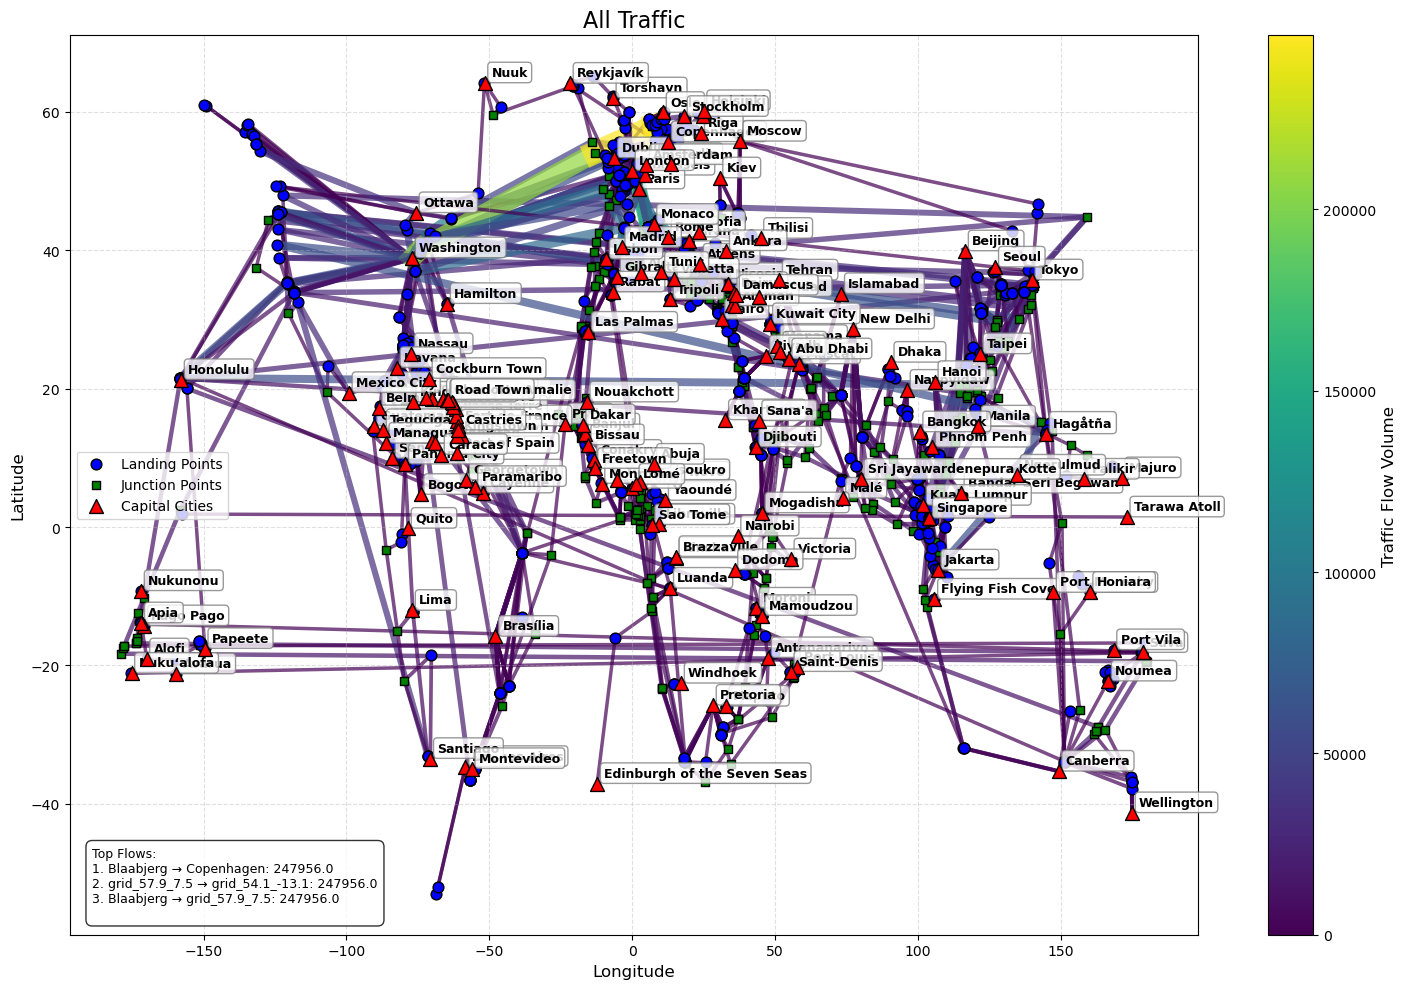

In [12]:
# Plot all traffic
plot_traffic(merged_data, nodes, traffic_col='traffic_all', title='All Traffic')

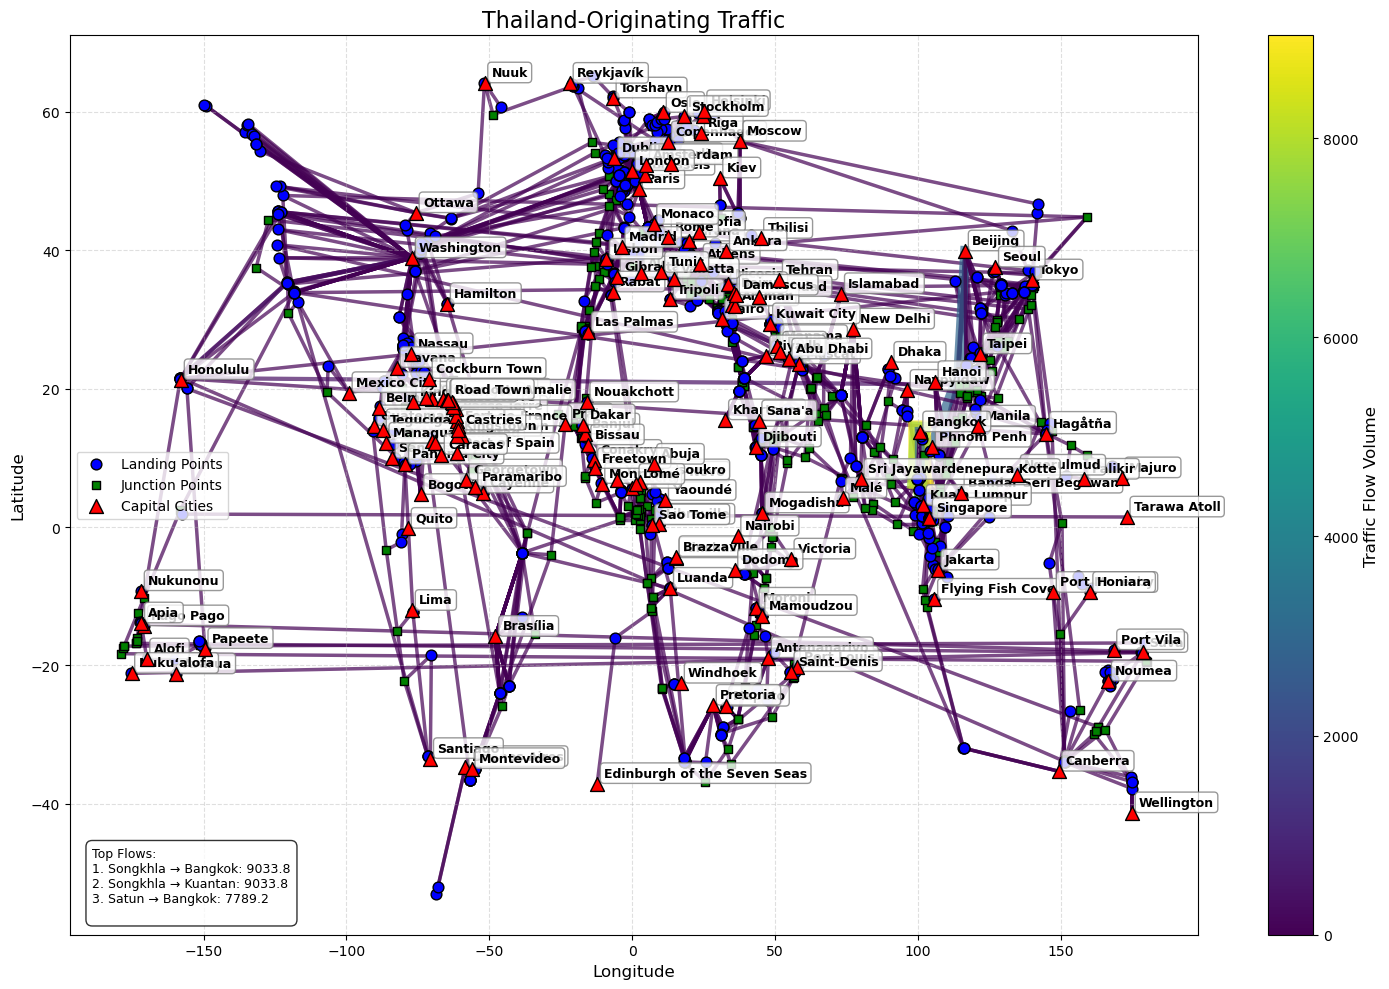

In [13]:
# Plot traffic for a specific country of interest
plot_traffic(merged_data, nodes, traffic_col='traffic_Thailand', title='Thailand-Originating Traffic')

In [ ]:
# Plot traffic for a specific country of interest
plot_traffic(merged_data, nodes, traffic_col='traffic_South_Africa', title='South Africa-Originating Traffic')

In [ ]:
# Plot traffic for a specific country of interest
plot_traffic(merged_data, nodes, traffic_col='traffic_United_States', title='US-Originating Traffic')

In [ ]:
# Example usage for Egypt
active_links_thailand = print_active_links(merged_data, 'traffic_Thailand')

In [ ]:
# 1. Get list of origin countries from OD data (excluding 'others')
countries = [c for c in od_matrices.keys() if c != 'others']

# 2. Create country links dataframe
country_links_data = []
for country in countries:
    # Get active links for this country
    active_links = results[results[f'traffic_{country.replace(" ", "_")}'] > 0].index
    
    # Get system_IDs for these links
    system_ids = links.loc[active_links, 'system_ID'].unique()
    
    country_links_data.append({
        'Origin Country': country,
        'Links Used': active_links.tolist(),
        'System_IDs': system_ids.tolist(),
        'Num Unique System_IDs': len(system_ids),
        'Num Links Used': len(active_links)
    })

# 3. Create dataframe
country_links = pd.DataFrame(country_links_data)

# 4. Calculate averages
avg_systems = country_links['Num Unique System_IDs'].mean()
avg_links = country_links['Num Links Used'].mean()

# 5. Add averages row
avg_row = pd.DataFrame({
    'Origin Country': ['Average'],
    'Links Used': [None],
    'System_IDs': [None],
    'Num Unique System_IDs': [avg_systems],
    'Num Links Used': [avg_links]
})

# 6. Combine and format
final_df = pd.concat([country_links, avg_row], ignore_index=True)
final_df = final_df[[
    'Origin Country', 
    'Num Links Used', 
    'Num Unique System_IDs',
    'System_IDs',
    'Links Used'
]]

# Formatting for readability
final_df['System_IDs'] = final_df['System_IDs'].apply(
    lambda x: ', '.join(map(str, x)) if isinstance(x, list) else x
)
final_df['Links Used'] = final_df['Links Used'].apply(
    lambda x: ', '.join(map(str, x)) if isinstance(x, list) else x
)


In [ ]:
final_df

In [14]:
merged_data

,Edge ID,Start Node,Start Name,Start Coordinates,End Node,End Name,End Coordinates,distance_km,system_ID,start_point_idx,...,Delay_factor_AB,Delay_factor_BA,Delay_factor_Max,VOC_AB,VOC_BA,VOC_max,PCE_AB,PCE_BA,PCE_tot,traffic_all
0,pt_54.5747_11.9311-pt_54.0833_12.1333,pt_54.5747_11.9311,"Gedser, Denmark","(11.9311, 54.5747)",pt_54.0833_12.1333,"Rostock, Germany","(12.1333, 54.0833)",56.257798,2000.10,1,...,3.906748,3.906748,3.906748,19.37832,19.37832,19.37832,19378.32,19378.32,38756.64,38756.64
1,pt_59.4372_24.745-pt_60.1708_24.9375,pt_59.4372_24.745,"Talinn, Estonia","(24.745, 59.4372)",pt_60.1708_24.9375,"Helsinki, Finland","(24.9375, 60.1708)",82.440640,2000.11,3,...,1.110850,1.110850,1.110850,0.73900,0.73900,0.73900,739.00,739.00,1478.00,1478.00
2,pt_54.5_11.2167-pt_54.6631_11.36,pt_54.5_11.2167,"Puttgarden, Germany","(11.2167, 54.5)",pt_54.6631_11.36,"Rõdbyhavn, Denmark","(11.36, 54.6631)",20.383229,2000.12,5,...,5.117893,5.117893,5.117893,27.45262,27.45262,27.45262,27452.62,27452.62,54905.24,54905.24
3,pt_39.603509_-74.338118-pt_32.304027_-64.756309,pt_39.603509_-74.338118,"Tuckerton, United States","(-74.3381182, 39.6035094)",pt_32.304027_-64.756309,"Bermuda, Bermuda","(-64.7563086, 32.3040273)",1183.232537,2000.13,7,...,2.319181,2.319181,2.319181,8.79454,8.79454,8.79454,8794.54,8794.54,17589.08,17589.08
4,pt_32.304027_-64.756309-pt_-3.730451_-38.525,pt_32.304027_-64.756309,"Bermuda, Bermuda","(-64.7563086, 32.3040273)",pt_-3.730451_-38.525,"Fortaleza, Brazil","(-38.525, -3.7304512)",4856.707511,2000.13,8,...,2.319181,2.319181,2.319181,8.79454,8.79454,8.79454,8794.54,8794.54,17589.08,17589.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509,pt_38.1157_13.3613-capital_Italy,pt_38.1157_13.3613,"Palermo, Italy","(13.3613, 38.1157)",capital_Italy,"Rome, Italy","(12.496366, 41.902784)",50.000000,NaN,1592,...,1.004650,1.004650,1.004650,0.03100,0.03100,0.03100,31.00,31.00,62.00,62.00
2510,pt_41.8931_12.4828-capital_Italy,pt_41.8931_12.4828,"Rome, Italy","(12.4828, 41.8931)",capital_Italy,"Rome, Italy","(12.496366, 41.902784)",50.000000,NaN,1593,...,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00,0.00
2511,pt_41.0038_9.6149-capital_Italy,pt_41.0038_9.6149,"Golfo Aranci, Italy","(9.6149, 41.0038)",capital_Italy,"Rome, Italy","(12.496366, 41.902784)",50.000000,NaN,1594,...,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00,0.00
2512,pt_42.7_9.4494-capital_France,pt_42.7_9.4494,"Bastia, France","(9.4494, 42.7)",capital_France,"Paris, France","(2.352222, 48.856614)",50.000000,NaN,1595,...,6.507490,6.507490,6.507490,36.71660,36.71660,36.71660,36716.60,36716.60,73433.20,73433.20


In [15]:
merged_data['Start Coordinates'] = merged_data['Start Coordinates'].apply(ast.literal_eval)
merged_data['End Coordinates'] = merged_data['End Coordinates'].apply(ast.literal_eval)
def longitude_in_range_safe(coord):
    try:
        lon = float(coord[0])
        return (150 <= lon <= 180) or (-180 <= lon <= -150)
    except (ValueError, TypeError, IndexError):
        return False

filtered_rows = merged_data[
    merged_data['Start Coordinates'].apply(longitude_in_range_safe) |
    merged_data['End Coordinates'].apply(longitude_in_range_safe)
]
filtered_rows

,Edge ID,Start Node,Start Name,Start Coordinates,End Node,End Name,End Coordinates,distance_km,system_ID,start_point_idx,...,Delay_factor_AB,Delay_factor_BA,Delay_factor_Max,VOC_AB,VOC_BA,VOC_max,PCE_AB,PCE_BA,PCE_tot,traffic_all
9,pt_35.3792_-120.8533-pt_21.4706_-158.2142,pt_35.3792_-120.8533,"Morro Bay, United States","(-120.8533, 35.3792)",pt_21.4706_-158.2142,"Makaha, nan","(-158.2142, 21.4706)",3941.921906,2000.14,16,...,2.546601,2.546601,2.546601,10.31067,10.31067,10.31067,10310.67,10310.67,20621.34,20621.34
10,pt_34.3282_136.8297-pt_21.4706_-158.2142,pt_34.3282_136.8297,"Shima, Japan","(136.8297, 34.3282)",pt_21.4706_-158.2142,"Makaha, nan","(-158.2142, 21.4706)",6445.905039,2000.14,18,...,2.546601,2.546601,2.546601,10.31067,10.31067,10.31067,10310.67,10310.67,20621.34,20621.34
37,pt_36.2306_140.3643-grid_44.8_159.0,pt_36.2306_140.3643,"Ajigaura, Japan","(140.3643, 36.2306)",grid_44.8_159.0,grid_44.8_159.0,"(159.0, 44.8)",1837.295858,2000.19,48,...,3.456366,3.456366,3.456366,16.37577,16.37577,16.37577,16375.77,16375.77,32751.54,32751.54
38,grid_44.8_159.0-pt_47.9161_-122.3031,grid_44.8_159.0,grid_44.8_159.0,"(159.0, 44.8)",pt_47.9161_-122.3031,"Harbour Pointe, United States","(-122.3031, 47.9161)",5794.562632,2000.19,49,...,3.365389,3.365389,3.365389,15.76926,15.76926,15.76926,15769.26,15769.26,31538.52,31538.52
39,pt_34.3282_136.8297-grid_44.8_159.0,pt_34.3282_136.8297,"Shima, Japan","(136.8297, 34.3282)",grid_44.8_159.0,grid_44.8_159.0,"(159.0, 44.8)",2220.832373,2000.19,51,...,2.819530,2.819530,2.819530,12.13020,12.13020,12.13020,12130.20,12130.20,24260.40,24260.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2385,pt_-22.2667_166.45-capital_New_Caledonia,pt_-22.2667_166.45,"Noumea, nan","(166.45, -22.2667)",capital_New_Caledonia,"Noumea, New Caledonia","(166.450524, -22.255823)",50.000000,NaN,1403,...,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00,0.00
2386,pt_-21.0_167.0-capital_New_Caledonia,pt_-21.0_167.0,"Quanono, nan","(167.0, -21.0)",capital_New_Caledonia,"Noumea, New Caledonia","(166.450524, -22.255823)",50.000000,NaN,1404,...,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00,0.00
2387,pt_-22.0_168.0-capital_New_Caledonia,pt_-22.0_168.0,"Tadine, nan","(168.0, -22.0)",capital_New_Caledonia,"Noumea, New Caledonia","(166.450524, -22.255823)",50.000000,NaN,1405,...,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00,0.00
2388,pt_-22.1667_166.95-capital_New_Caledonia,pt_-22.1667_166.95,"Yate, nan","(166.95, -22.1667)",capital_New_Caledonia,"Noumea, New Caledonia","(166.450524, -22.255823)",50.000000,NaN,1406,...,1.000000,1.000000,1.000000,0.00000,0.00000,0.00000,0.00,0.00,0.00,0.00


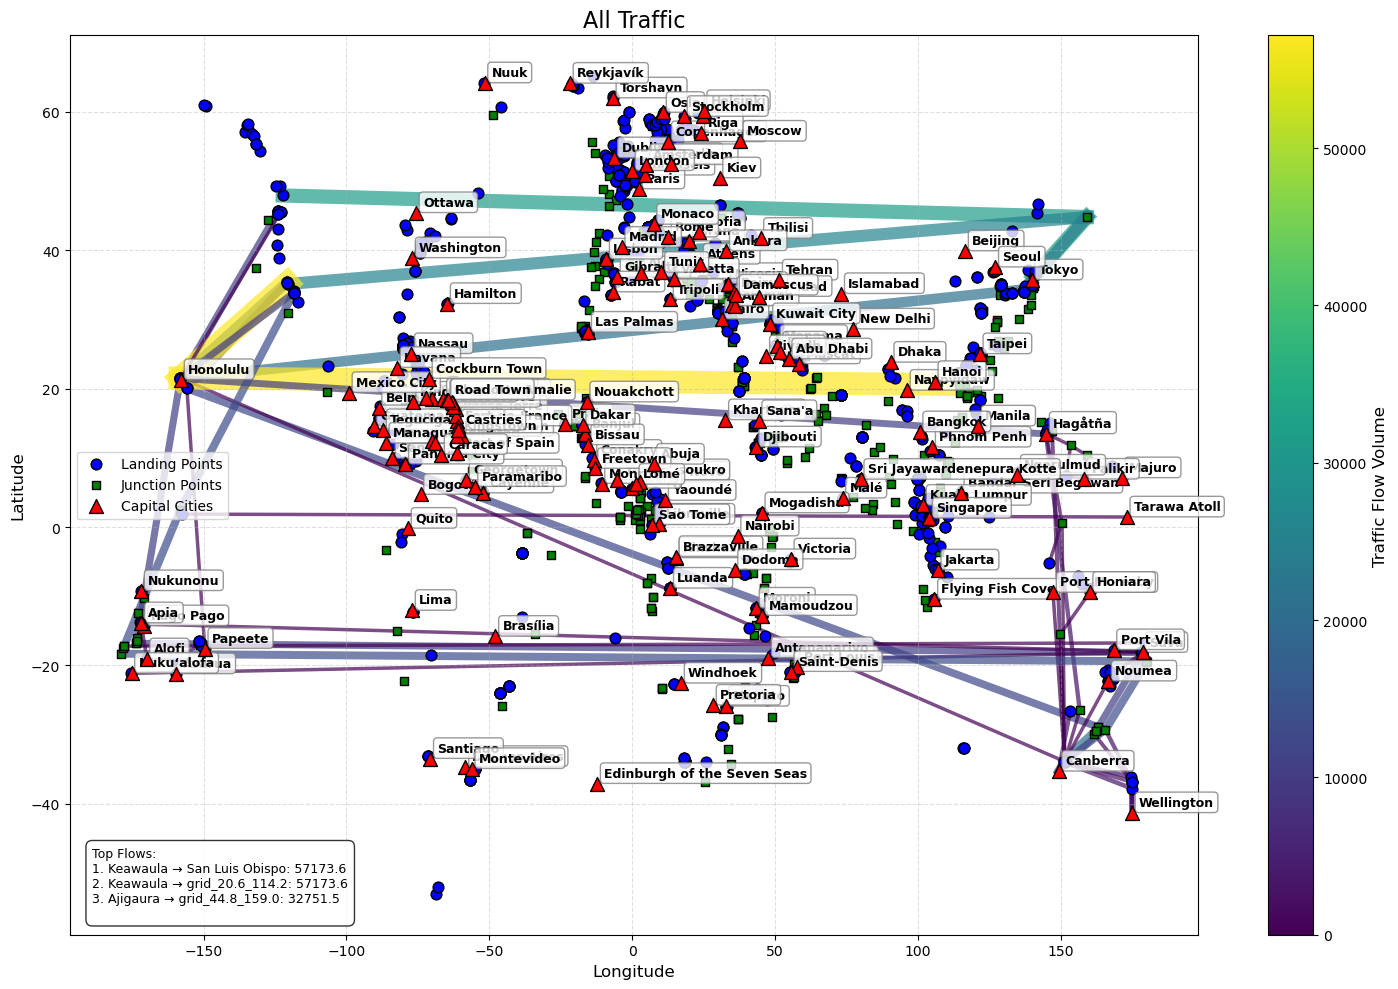

In [16]:
# Plot all traffic
plot_traffic(filtered_rows, nodes, traffic_col='traffic_all', title='All Traffic')

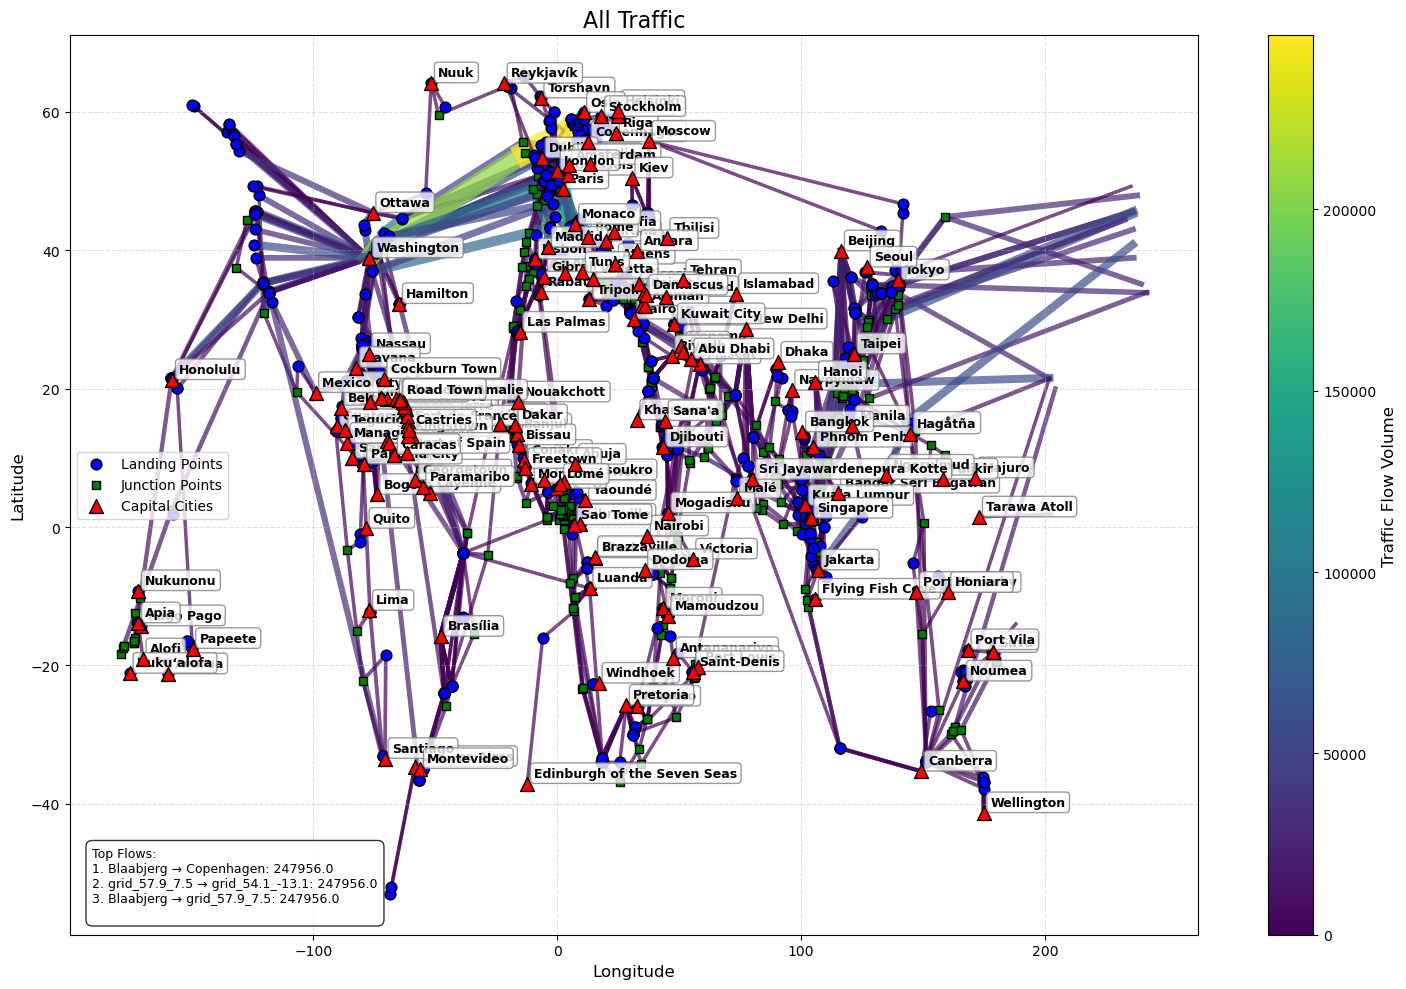

In [21]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def unwrap_antimeridian(start, end):
    lon1, lat1 = start
    lon2, lat2 = end
    # If one longitude > 150 and the other < -150, adjust for plotting
    if lon1 > 100 and lon2 < -100:
        lon2 += 360
    elif lon2 > 100 and lon1 < -100:
        lon1 += 360
    return (lon1, lat1), (lon2, lat2)


def plot_traffic(merged_data, nodes, traffic_col='traffic_all', title=None):
    fig, ax = plt.subplots(figsize=(15, 10))
    max_flow = merged_data[traffic_col].max()
    norm = mcolors.Normalize(vmin=0, vmax=max_flow)
    cmap = plt.cm.viridis

    for _, link in merged_data.iterrows():
        start_node = nodes[nodes['Hop_ID'] == link['start_point_idx']]
        end_node = nodes[nodes['Hop_ID'] == link['end_point_idx']]
        if not start_node.empty and not end_node.empty:
            width = 2.5 + 14 * (link[traffic_col] / max_flow if max_flow > 0 else 0)

            start_coords = (start_node['Longitude'].values[0], start_node['Latitude'].values[0])
            end_coords = (end_node['Longitude'].values[0], end_node['Latitude'].values[0])

            # Unwrap antimeridian if needed
            (lon1, lat1), (lon2, lat2) = unwrap_antimeridian(start_coords, end_coords)

            ax.plot(
                [lon1, lon2],
                [lat1, lat2],
                color=cmap(norm(link[traffic_col])),
                linewidth=width,
                alpha=0.7,
                zorder=1
            )

    # Plot nodes
    landing_points = nodes[nodes['Node ID'].str.startswith('pt')]
    ax.scatter(
        landing_points['Longitude'], landing_points['Latitude'],
        color='blue', s=60, marker='o', edgecolor='black', linewidth=1,
        label='Landing Points', zorder=3
    )
    grid_points = nodes[nodes['Node ID'].str.startswith('grid')]
    ax.scatter(
        grid_points['Longitude'], grid_points['Latitude'],
        color='green', s=40, marker='s', edgecolor='black', linewidth=1,
        label='Junction Points', zorder=2
    )
    capitals = nodes[nodes['Node ID'].str.startswith('capital')]
    ax.scatter(
        capitals['Longitude'], capitals['Latitude'],
        color='red', s=100, marker='^', edgecolor='black', linewidth=1,
        label='Capital Cities', zorder=4
    )
    for _, capital in capitals.iterrows():
        city_name = capital['Name'].split(',')[0]
        ax.annotate(
            city_name,
            (capital['Longitude'], capital['Latitude']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Traffic Flow Volume', fontsize=12)
    ax.set_title(title or f'Traffic Flows: {traffic_col}', fontsize=16)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='center left')

    # Add text showing top flows
    top_flows = merged_data.sort_values(traffic_col, ascending=False).head(3)
    flow_text = "Top Flows:\n"
    for i, (_, flow) in enumerate(top_flows.iterrows(), 1):
        if 'Start Name' in flow and 'End Name' in flow:
            start = flow['Start Name'].split(',')[0] if ',' in flow['Start Name'] else flow['Start Name']
            end = flow['End Name'].split(',')[0] if ',' in flow['End Name'] else flow['End Name']
            flow_text += f"{i}. {start} → {end}: {flow[traffic_col]:.1f}\n"
    ax.text(0.02, 0.02, flow_text, transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
            fontsize=9)

    plt.tight_layout()
    plt.show()
# Plot all traffic
plot_traffic(merged_data, nodes, traffic_col='traffic_all', title='All Traffic')

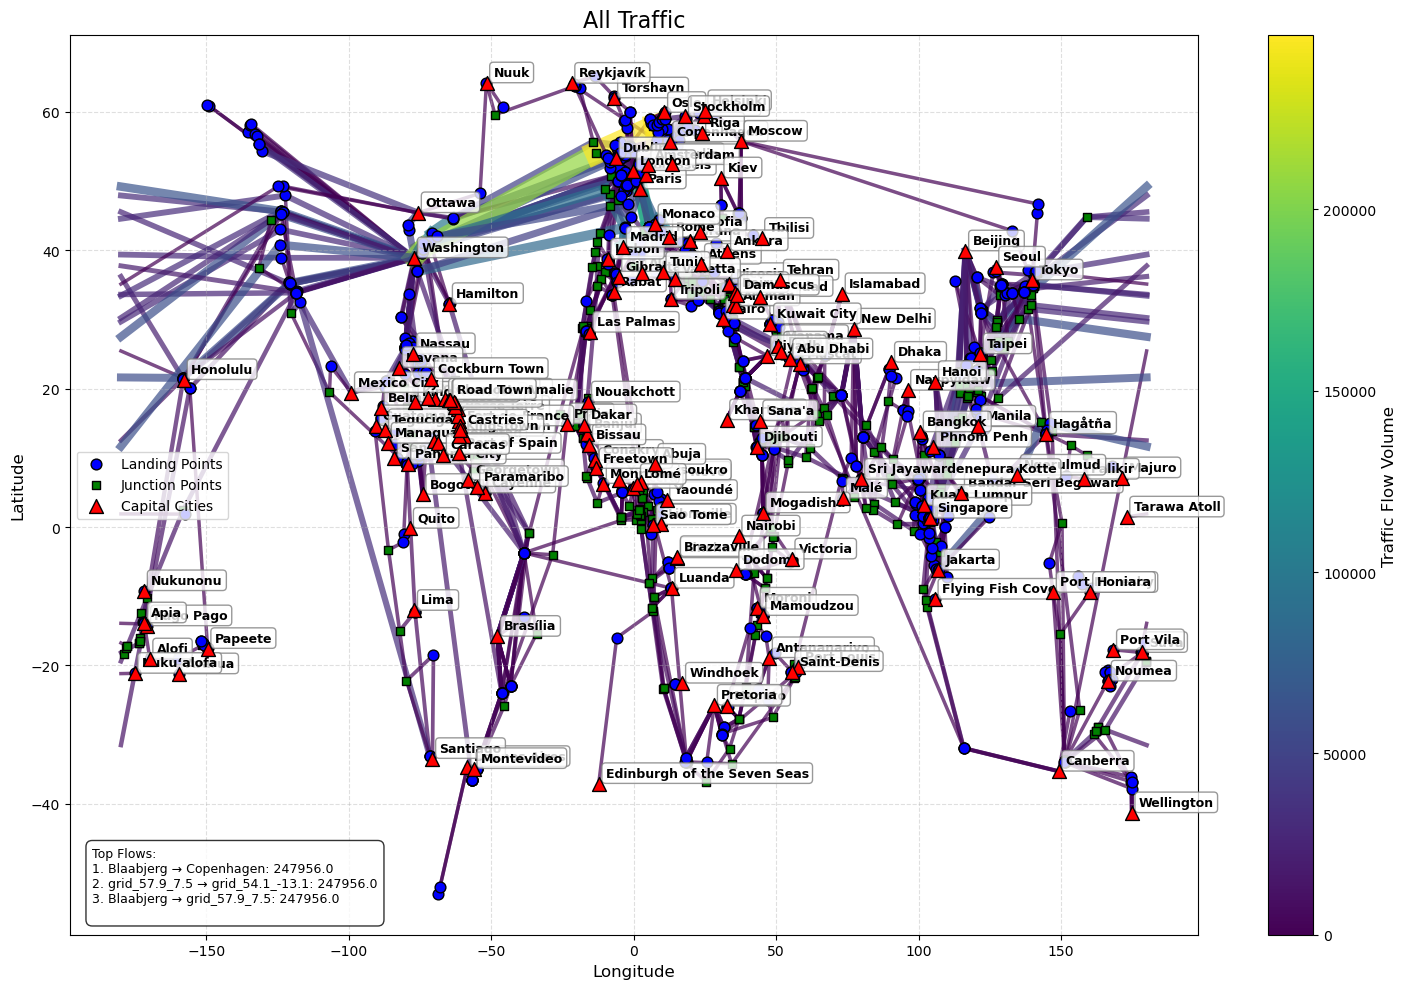

In [25]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def split_antimeridian_line(start, end):
    lon1, lat1 = start
    lon2, lat2 = end
    
    # Check if line crosses antimeridian
    if abs(lon1 - lon2) <= 180:
        # No crossing, return as is
        return [((lon1, lat1), (lon2, lat2))]
    
    # Crossing detected: split into two segments
    crossing_lon = 180 if lon1 > 0 else -180
    
    # Linear interpolation to find crossing latitude
    if lon2 != lon1:
        ratio = (crossing_lon - lon1) / (lon2 - lon1)
    else:
        ratio = 0.5  # Arbitrary if same longitude
    
    crossing_lat = lat1 + ratio * (lat2 - lat1)
    
    # First segment: start to crossing point
    segment1_end = (crossing_lon, crossing_lat)
    # Second segment: crossing point (wrapped) to end
    if lon1 > lon2:
        segment2_start = (crossing_lon - 360, crossing_lat)
    else:
        segment2_start = (crossing_lon + 360, crossing_lat)
    
    return [((lon1, lat1), segment1_end), (segment2_start, (lon2, lat2))]

def plot_traffic(merged_data, nodes, traffic_col='traffic_all', title=None):
    fig, ax = plt.subplots(figsize=(15, 10))
    max_flow = merged_data[traffic_col].max()
    norm = mcolors.Normalize(vmin=0, vmax=max_flow)
    cmap = plt.cm.viridis

    for _, link in merged_data.iterrows():
        start_node = nodes[nodes['Hop_ID'] == link['start_point_idx']]
        end_node = nodes[nodes['Hop_ID'] == link['end_point_idx']]
        if not start_node.empty and not end_node.empty:
            width = 2.5 + 14 * (link[traffic_col] / max_flow if max_flow > 0 else 0)

            start_coords = (start_node['Longitude'].values[0], start_node['Latitude'].values[0])
            end_coords = (end_node['Longitude'].values[0], end_node['Latitude'].values[0])

            # Split line if crossing antimeridian
            segments = split_antimeridian_line(start_coords, end_coords)
            for seg_start, seg_end in segments:
                ax.plot(
                    [seg_start[0], seg_end[0]],
                    [seg_start[1], seg_end[1]],
                    color=cmap(norm(link[traffic_col])),
                    linewidth=width,
                    alpha=0.7,
                    zorder=1
                )

    # Plot nodes (same as your original code)
    landing_points = nodes[nodes['Node ID'].str.startswith('pt')]
    ax.scatter(
        landing_points['Longitude'], landing_points['Latitude'],
        color='blue', s=60, marker='o', edgecolor='black', linewidth=1,
        label='Landing Points', zorder=3
    )
    grid_points = nodes[nodes['Node ID'].str.startswith('grid')]
    ax.scatter(
        grid_points['Longitude'], grid_points['Latitude'],
        color='green', s=40, marker='s', edgecolor='black', linewidth=1,
        label='Junction Points', zorder=2
    )
    capitals = nodes[nodes['Node ID'].str.startswith('capital')]
    ax.scatter(
        capitals['Longitude'], capitals['Latitude'],
        color='red', s=100, marker='^', edgecolor='black', linewidth=1,
        label='Capital Cities', zorder=4
    )
    for _, capital in capitals.iterrows():
        city_name = capital['Name'].split(',')[0]
        ax.annotate(
            city_name,
            (capital['Longitude'], capital['Latitude']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Traffic Flow Volume', fontsize=12)
    ax.set_title(title or f'Traffic Flows: {traffic_col}', fontsize=16)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='center left')

    # Add text showing top flows
    top_flows = merged_data.sort_values(traffic_col, ascending=False).head(3)
    flow_text = "Top Flows:\n"
    for i, (_, flow) in enumerate(top_flows.iterrows(), 1):
        if 'Start Name' in flow and 'End Name' in flow:
            start = flow['Start Name'].split(',')[0] if ',' in flow['Start Name'] else flow['Start Name']
            end = flow['End Name'].split(',')[0] if ',' in flow['End Name'] else flow['End Name']
            flow_text += f"{i}. {start} → {end}: {flow[traffic_col]:.1f}\n"
    ax.text(0.02, 0.02, flow_text, transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
            fontsize=9)

    plt.tight_layout()
    plt.show()
# Plot all traffic
plot_traffic(merged_data, nodes, traffic_col='traffic_all', title='All Traffic')